# Task 1 — Initial EDA: Brent Oil Prices

Loads the daily Brent oil price series, checks trend/stationarity/volatility properties, and produces the plots needed for the interim submission.

**Data note:** if `data/raw/BrentOilPrices.csv` is not present, this notebook falls back to a clearly-labeled **synthetic placeholder series** (same schema: `Date`, `Price`) so the analysis code can be reviewed end-to-end. Drop the real file in `data/raw/BrentOilPrices.csv` (columns `Date` in `dd-Mon-yy` format, `Price` in USD/barrel) and re-run to get the actual results.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams['figure.figsize'] = (12, 5)
RAW_PATH = '../data/raw/BrentOilPrices.csv'
USING_SYNTHETIC = not os.path.exists(RAW_PATH)
USING_SYNTHETIC

True

In [2]:
if USING_SYNTHETIC:
    print('BrentOilPrices.csv not found — generating a SYNTHETIC placeholder series for demonstration only.')
    rng = np.random.default_rng(42)
    dates = pd.date_range('1987-05-20', '2022-09-30', freq='B')
    n = len(dates)
    # rough regime structure loosely mimicking known history, for illustration only
    steps = rng.normal(0, 0.012, n)
    regime_shifts = {int(n*0.55): 0.9, int(n*0.62): -1.1, int(n*0.80): -1.4, int(n*0.97): 1.0}
    log_price = np.cumsum(steps) + np.log(20)
    for idx, jump in regime_shifts.items():
        log_price[idx:] += jump
    price = np.exp(log_price) + 10
    df = pd.DataFrame({'Date': dates, 'Price': price})
else:
    df = pd.read_csv(RAW_PATH)

df.head()

BrentOilPrices.csv not found — generating a SYNTHETIC placeholder series for demonstration only.


,Date,Price
0,1987-05-20,30.073266
1,1987-05-21,29.824312
2,1987-05-22,30.003645
3,1987-05-25,30.230700
4,1987-05-26,29.762552


In [3]:
# Parse dates (real file uses dd-Mon-yy, e.g. 20-May-87)
if not USING_SYNTHETIC:
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

print(f"Rows: {len(df)}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Missing values: {df['Price'].isna().sum()}")
print(f"Duplicate dates: {df.index.duplicated().sum()}")
df.describe()

Rows: 9228
Date range: 1987-05-20 to 2022-09-30
Missing values: 0
Duplicate dates: 0


,Price
count,9228.000000
mean,19.166632
std,4.852630
min,11.451778
25%,15.773058
50%,18.699776
75%,22.703448
max,31.359653


## Raw price series

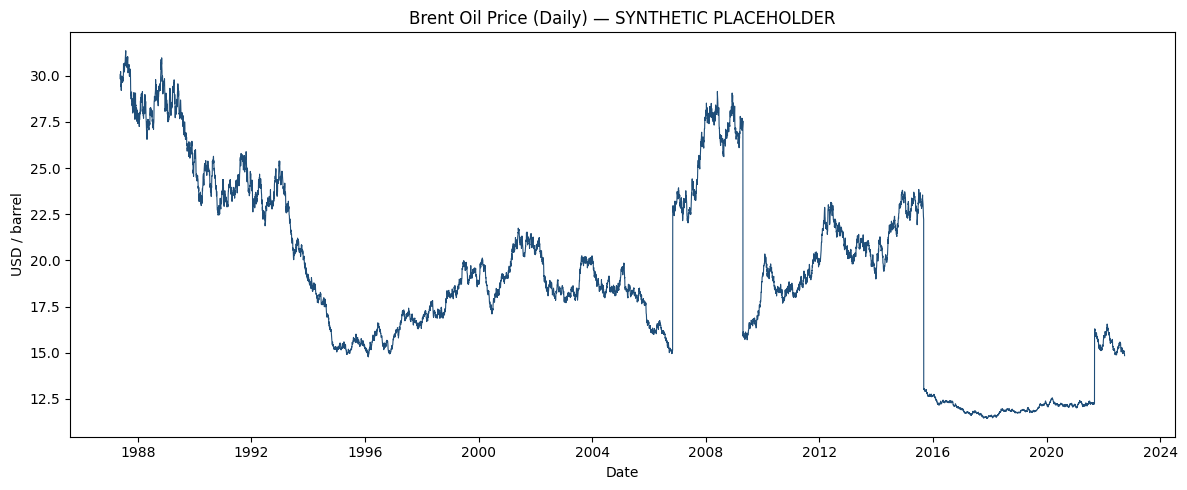

In [4]:
fig, ax = plt.subplots()
ax.plot(df.index, df['Price'], linewidth=0.8, color='#1f4e79')
ax.set_title('Brent Oil Price (Daily)' + (' — SYNTHETIC PLACEHOLDER' if USING_SYNTHETIC else ''))
ax.set_xlabel('Date')
ax.set_ylabel('USD / barrel')
plt.tight_layout()
plt.savefig('../reports/fig_raw_price.png', dpi=150)
plt.show()

## Log returns and volatility

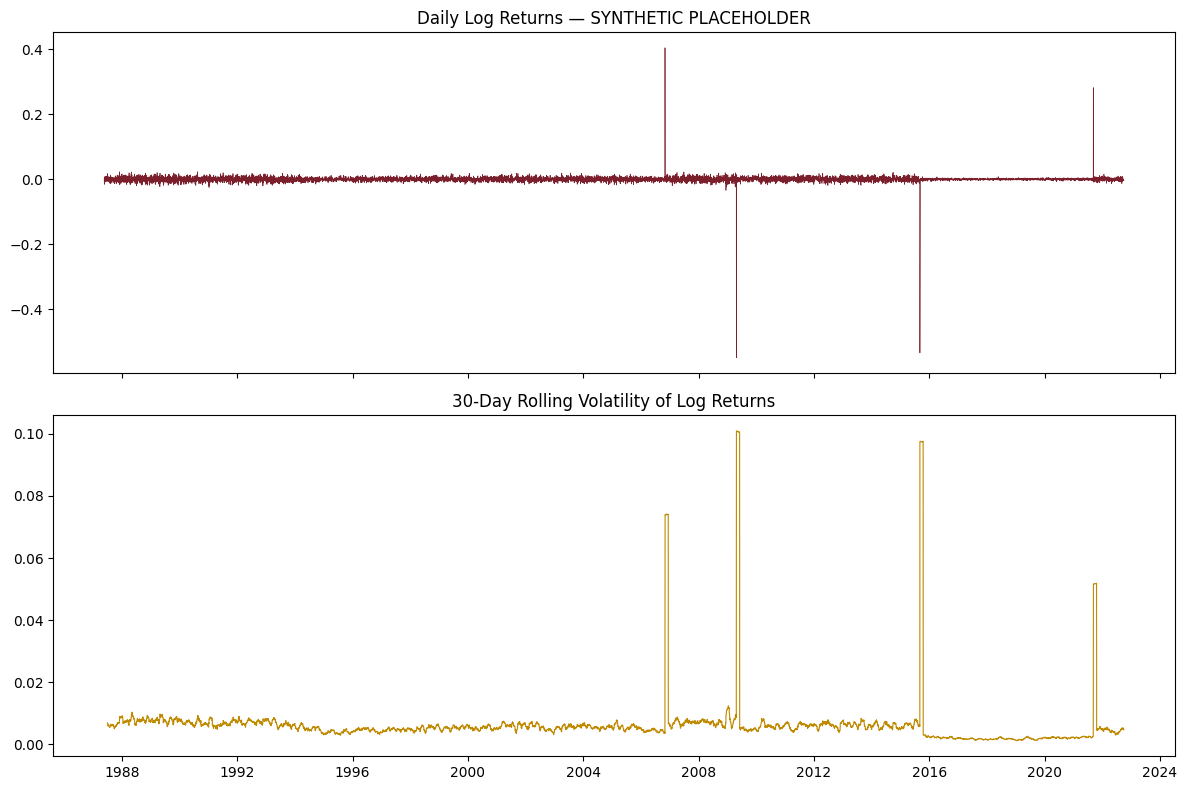

In [5]:
df['log_price'] = np.log(df['Price'])
df['log_return'] = df['log_price'].diff()
df['rolling_vol_30d'] = df['log_return'].rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df.index, df['log_return'], linewidth=0.5, color='#7a1f2b')
axes[0].set_title('Daily Log Returns' + (' — SYNTHETIC PLACEHOLDER' if USING_SYNTHETIC else ''))
axes[1].plot(df.index, df['rolling_vol_30d'], linewidth=0.8, color='#c08a00')
axes[1].set_title('30-Day Rolling Volatility of Log Returns')
plt.tight_layout()
plt.savefig('../reports/fig_returns_volatility.png', dpi=150)
plt.show()

Volatility clustering (periods of persistently high/low volatility) is visible above — a hallmark of financial time series and a signal that a simple constant-variance mean-shift model is a simplification worth flagging as a limitation.

## Stationarity tests

ADF null hypothesis: series has a unit root (non-stationary). KPSS null hypothesis: series is stationary. Running both guards against relying on a single test.

In [6]:
def run_stationarity_tests(series, label):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    print(f"--- {label} ---")
    print(f"ADF statistic: {adf_stat:.4f}, p-value: {adf_p:.4f} -> {'stationary' if adf_p < 0.05 else 'non-stationary'} (ADF)")
    print(f"KPSS statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f} -> {'non-stationary' if kpss_p < 0.05 else 'stationary'} (KPSS)")
    print()

run_stationarity_tests(df['Price'], 'Raw Price')
run_stationarity_tests(df['log_return'], 'Log Returns')

/tmp/ipykernel_702/580680630.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')


--- Raw Price ---
ADF statistic: -2.6468, p-value: 0.0837 -> non-stationary (ADF)
KPSS statistic: 5.3911, p-value: 0.0100 -> non-stationary (KPSS)



--- Log Returns ---
ADF statistic: -95.0862, p-value: 0.0000 -> stationary (ADF)
KPSS statistic: 0.0539, p-value: 0.1000 -> stationary (KPSS)



/tmp/ipykernel_702/580680630.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')


**Expected pattern:** the raw price series is typically non-stationary (ADF fails to reject unit root; KPSS rejects stationarity) since it trends and shifts level over decades. Log returns are typically much closer to stationary (mean-reverting around zero), which is why Task 2's change point model is applied to returns rather than raw price levels — this satisfies the constant-mean/constant-variance-around-a-mean assumption of a simple `pm.Normal` likelihood far better than the raw series does.

## Next steps (Task 2)

1. Build the PyMC change point model on `log_return` with a `DiscreteUniform` prior over `tau`.
2. Define `mu_1`, `mu_2` (and optionally `sigma_1`, `sigma_2`) with `pm.math.switch` selecting the active regime.
3. Sample with `pm.sample()`, check `pm.summary()` / `pm.plot_trace()` for convergence.
4. Compare the posterior mode of `tau` against `data/events/brent_oil_key_events.csv` to form hypotheses.
5. Quantify the shift in mean daily return / price level before vs. after and report probabilistically.